In [1]:
import pandas as pd
import matplotlib.pyplot  as plt
from metrics import metrics
from model import generics
from scipy.stats import wilcoxon
pd.set_option('display.max_rows', 2000)

%load_ext autoreload
%autoreload 2

In [2]:
experiment_id = 'irradiance'

In [5]:
df_mean_metrics, df_all_metrics, df_prevs = metrics.open_fold_result(experiment_id)

In [6]:
df_mean_metrics.reset_index().sort_values(by=['ts', 'model'])[
    ['ts', 'model', 'MSE' ,'RMSE',	'MAPE', 'MAE']
] #721.123525	26.853743	63.562772	20.192241

,ts,model,MSE,RMSE,MAPE,MAE
0,irradiancecabrobo,1ma,1.350136e+06,1161.953422,7747.935489,1012.962429
1,irradiancecabrobo,1mlp,1.053036e+05,324.492692,448.797189,238.398865
2,irradiancecabrobo,1rw,3.898303e+05,624.363891,1573.880219,523.450000
3,irradiancecabrobo,1svr,8.927101e+04,298.782548,544.244793,202.430796
4,irradianceouricuri,1ma,1.348903e+06,1161.422934,1636.483542,1015.502054
5,irradianceouricuri,1mlp,1.169799e+05,342.016378,102.916527,252.572382
6,irradianceouricuri,1rw,3.830199e+05,618.886042,185.134626,518.408684
7,irradianceouricuri,1svr,9.691300e+04,311.308527,50.611345,206.604117
8,irradiancesalgueiro,1ma,1.373448e+06,1171.941931,1060.676476,1015.113405
9,irradiancesalgueiro,1mlp,1.298554e+05,360.346059,78.539605,267.836514


In [45]:
metric = 'RMSE'

proposed_list = []
for k, df in df_mean_metrics.reset_index().groupby('ts'):
    #arima = df[df['model'] == 'arima'][metric].iloc[0]
    #svr = df[df['model'] == 'arima'][metric].iloc[0]
    #mlp = df[df['model'] == 'arima'][metric].iloc[0]

    #df_arima[k] = (df.set_index('model')[metric] < arima)
    #df_svr[k] = (df.set_index('model')[metric] < svr)
    #df_mlp[k] = (df.set_index('model')[metric] < mlp)

    svr_proposed = df[( (df['model'].str.contains("1ammeanenscdsrc12k10")))].copy()
    if svr_proposed.shape[0]>0:
        proposed_list.append(pd.DataFrame(svr_proposed.iloc[svr_proposed['val_metric'].argmin()]).T)

    mlp_proposed = df[( (df['model'].str.contains("mlpkpssfalsep")) )].copy()
    if mlp_proposed.shape[0]>0:
        proposed_list.append(pd.DataFrame(mlp_proposed.iloc[mlp_proposed['val_metric'].argmin()]).T)
    order_personalizada =  [ 
               #'1mlp', 
              
              #'1ammean100', 
              #'1as', 
              #'1asens', 
              ##'1am' ,
               '1aquant',
               '1aquantmean100', 
              
              #'1ammean100cdsrc0.1k20', '1ammean100cdsrc0.1k40', '1ammean100cdsrc0.1k80' , 
              #'1ammean100cmostrecentrc1k20', '1ammean100cmostrecentrc1k40', '1ammean100cmostrecentrc1k80', 
               '1aquantmean100cdsrc0.1k20', '1aquantmean100cdsrc0.1k40', '1aquantmean100cdsrc0.1k80',
               '1aquantmean100cmostrecentrc1k20', '1aquantmean100cmostrecentrc1k40', '1aquantmean100cmostrecentrc1k80', 
               #'1asenscdsrc0.1k20',  '1asenscdsrc0.1k40',  '1asenscdsrc0.1k80',
               #'1asenscmostrecentrc1k20',  '1asenscmostrecentrc1k40', '1asenscmostrecentrc1k80',
                '1arima',
                '1svr', 
            ]
    proposed_list.append(
        df[df['model'].isin(
            order_personalizada
        )]
    )

In [46]:
df_show = pd.concat(proposed_list)[['ts', 'model', 'RMSE', 'MAPE', 'MAE']]

df_show['model'] = pd.Categorical(df_show['model'], categories=order_personalizada, ordered=True)

In [47]:
df_show.sort_values(['ts', 'model'])

,ts,model,RMSE,MAPE,MAE
28,Unemployment,1aquant,45.081526,6.320693,36.751223
29,Unemployment,1aquantmean100,45.079596,6.312001,36.752962
32,Unemployment,1aquantmean100cdsrc0.1k20,42.930653,5.808740,34.024306
33,Unemployment,1aquantmean100cdsrc0.1k40,43.460894,5.918160,34.621649
35,Unemployment,1aquantmean100cdsrc0.1k80,44.485664,6.156982,35.898046
50,Unemployment,1aquantmean100cmostrecentrc1k20,46.380827,6.407155,37.494313
51,Unemployment,1aquantmean100cmostrecentrc1k40,46.126911,6.388280,37.350009
53,Unemployment,1aquantmean100cmostrecentrc1k80,45.479997,6.330263,36.940004
54,Unemployment,1arima,50.330156,6.853486,40.808348
83,Unemployment,1svr,68.018585,9.358500,56.577485


('majaboataosamu',)


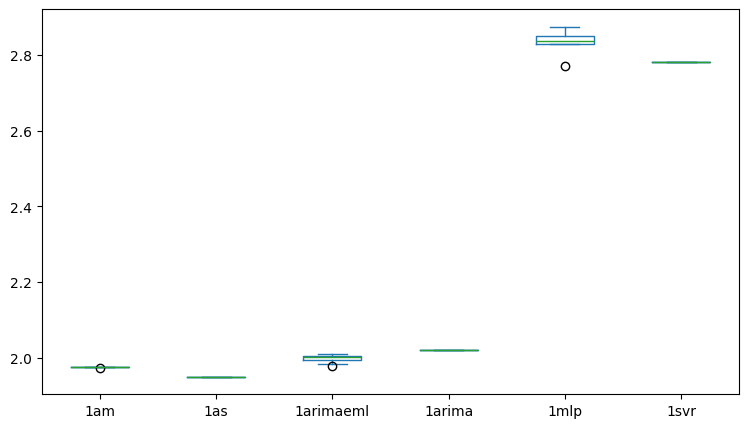

,base,1am,1arima,1arimaeml,1as,1elm,1ma,1mlp,1rw,1svr
0,1am,'=,'+,'+,'-,'+,'+,'+,'+,'+
1,1arima,'-,'=,'+,'-,'+,'+,'+,'+,'+
2,1arimaeml,'-,'-,'=,'-,'+,'+,'+,'+,'+
3,1as,'+,'+,'+,'=,'+,'+,'+,'+,'+
4,1elm,'-,'-,'-,'-,'=,'+,'-,'+,'-
5,1ma,'-,'-,'-,'-,'-,'=,'-,'-,'-
6,1mlp,'-,'-,'-,'-,'+,'+,'=,'+,'-
7,1rw,'-,'-,'-,'-,'-,'+,'-,'=,'-
8,1svr,'-,'-,'-,'-,'+,'+,'+,'+,'=


('maolindasamu',)


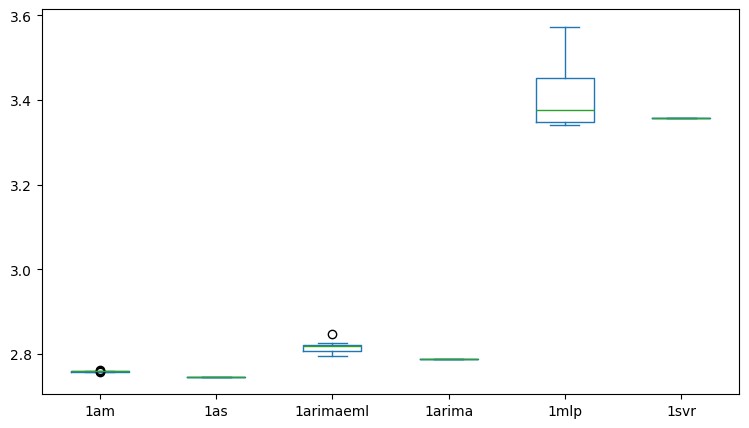

,base,1am,1arima,1arimaeml,1as,1elm,1ma,1mlp,1rw,1svr
0,1am,'=,'+,'+,'-,'+,'+,'+,'+,'+
1,1arima,'-,'=,'+,'-,'+,'+,'+,'+,'+
2,1arimaeml,'-,'-,'=,'-,'+,'+,'+,'+,'+
3,1as,'+,'+,'+,'=,'+,'+,'+,'+,'+
4,1elm,'-,'-,'-,'-,'=,'+,'=,'-,'-
5,1ma,'-,'-,'-,'-,'-,'=,'-,'-,'-
6,1mlp,'-,'-,'-,'-,'=,'+,'=,'=,'=
7,1rw,'-,'-,'-,'-,'+,'+,'=,'=,'-
8,1svr,'-,'-,'-,'-,'+,'+,'=,'+,'=


('mapaulistasamu',)


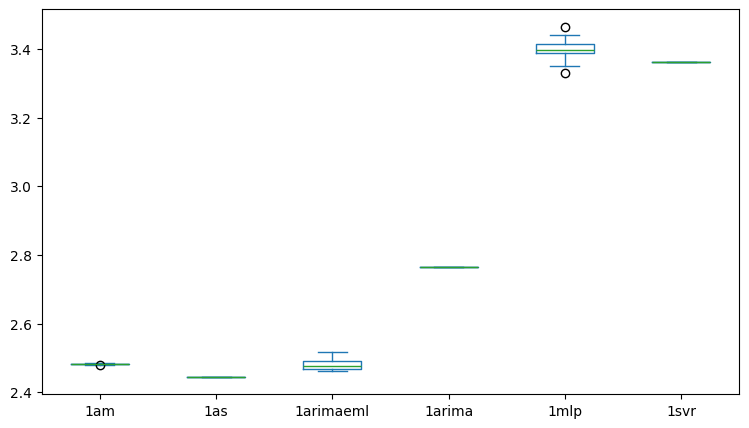

,base,1am,1arima,1arimaeml,1as,1elm,1ma,1mlp,1rw,1svr
0,1am,'=,'+,'+,'+,'+,'+,'+,'+,'+
1,1arima,'-,'=,'-,'-,'+,'+,'+,'+,'+
2,1arimaeml,'-,'+,'=,'=,'+,'+,'+,'+,'+
3,1as,'-,'+,'=,'=,'+,'+,'+,'+,'+
4,1elm,'-,'-,'-,'-,'=,'+,'=,'+,'-
5,1ma,'-,'-,'-,'-,'-,'=,'-,'-,'-
6,1mlp,'-,'-,'-,'-,'=,'+,'=,'=,'-
7,1rw,'-,'-,'-,'-,'-,'+,'=,'=,'-
8,1svr,'-,'-,'-,'-,'+,'+,'+,'+,'=


('marecifesamu',)


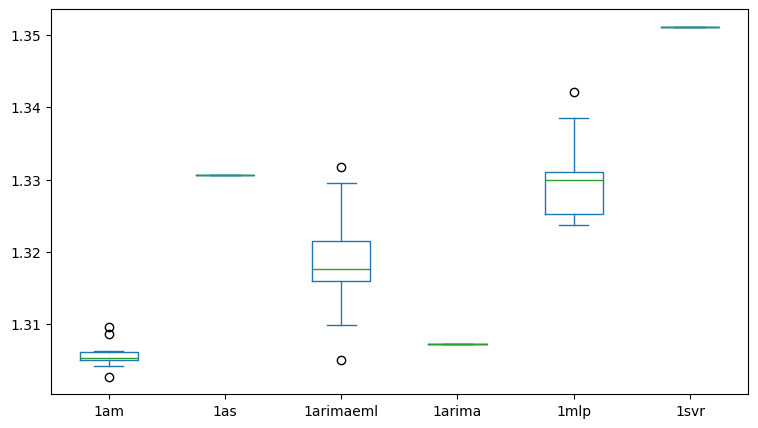

,base,1am,1arima,1arimaeml,1as,1elm,1ma,1mlp,1rw,1svr
0,1am,'=,'+,'=,'+,'+,'+,'+,'+,'+
1,1arima,'-,'=,'=,'+,'+,'+,'+,'+,'+
2,1arimaeml,'=,'=,'=,'+,'+,'+,'+,'+,'+
3,1as,'-,'-,'-,'=,'+,'+,'+,'+,'+
4,1elm,'-,'-,'-,'-,'=,'+,'-,'+,'-
5,1ma,'-,'-,'-,'-,'-,'=,'-,'-,'-
6,1mlp,'-,'-,'-,'-,'+,'+,'=,'+,'+
7,1rw,'-,'-,'-,'-,'-,'+,'-,'=,'-
8,1svr,'-,'-,'-,'-,'+,'+,'-,'+,'=


In [19]:
def get_hipotesis(metrics_p1, metrics_p2):
    stat, p = wilcoxon(metrics_p1, metrics_p2, alternative='two-sided')
    # interpret
    alpha = 0.05
    if p > alpha:
        #print('Same distribution (fail to reject H0)')
        to_print = '\'='
    else:
        stat, p = wilcoxon(metrics_p1, metrics_p2, alternative='less')
        if p > alpha:
             to_print = '\'-'
        else:
            to_print = '\'+'
        #print('Different distribution (reject H0)')

    return to_print

def columns_x_columns(df_pivot):
    all_comparasion = []
    for c1 in df_pivot.columns:
        result_base = {}
        result_base['base'] = c1 
        for c2 in df_pivot.columns:
            if c1!=c2:
                result = get_hipotesis(df_pivot[c1], df_pivot[c2])
                result_base[c2] = result
            else:
                result_base[c2] = '\'='
        all_comparasion.append(result_base)
    display(pd.DataFrame(all_comparasion))

all_execs = []
for key, df_serie in df_all_metrics.groupby(['ts']):
    print(key)
    df_pivot = df_serie.pivot(columns= 'model', values='RMSE' )
    df_pivot = df_pivot.ffill()
    df_serie.pivot(columns= 'model', values='MAPE' )[['1am', '1as', '1arimaeml', '1arima', '1mlp', '1svr']].plot.box(figsize = (9,5))
    plt.show()
    columns_x_columns(df_pivot)